# Beyond the Headlines: A Data-Driven Analysis of the UK Asylum System
**Author:** SOUVIK MITRA | **Data Source:** UK Home Office Immigration Statistics (Year Ending Sept 2025)

### Project Objective
This analysis cuts through political rhetoric to examine the actual data behind UK asylum claims. By processing raw OpenDocument Spreadsheets (`.ods`) published by the Home Office, this project visualizes claim volumes, demographic shifts, entry routes, judicial appeal outcomes, and the operational impact of the processing backlog.


In [1]:
# ==========================================
# 1. System Setup and Helper Functions
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.subplots as sp
import warnings
warnings.filterwarnings('ignore') # Keeps the notebook clean from pandas version warnings

FILE_PATH = 'asylum-summary-sep-2025-tables.ods'

def load_ho_sheet(sheet_name, skiprows=5):
    """Helper function to load and perform baseline cleaning on Home Office ODS sheets."""
    df = pd.read_excel(FILE_PATH, engine='odf', sheet_name=sheet_name, skiprows=skiprows)
    df = df.dropna(how='all', axis=1).dropna(how='all', axis=0)

    # Rename first column to 'Category' uniformly
    df.rename(columns={df.columns[0]: 'Category'}, inplace=True)

    # Clean float-years in headers (e.g., converts 2014.0 to '2014')
    df.columns = [str(col).replace('.0', '') for col in df.columns]

    # Clean whitespace from category names
    if df['Category'].dtype == 'object':
        df['Category'] = df['Category'].astype(str).str.strip()

    return df

print("Environment setup complete. Helper functions initialized.")

Environment setup complete. Helper functions initialized.


### 1. The Processing Gap & Operational Impact
The system faced unprecedented volume starting in 2021, leading to a massive processing backlog. We can visualize this gap by comparing incoming applications to outgoing grants, and subsequently tracking the rising number of people requiring Section 95 government support.

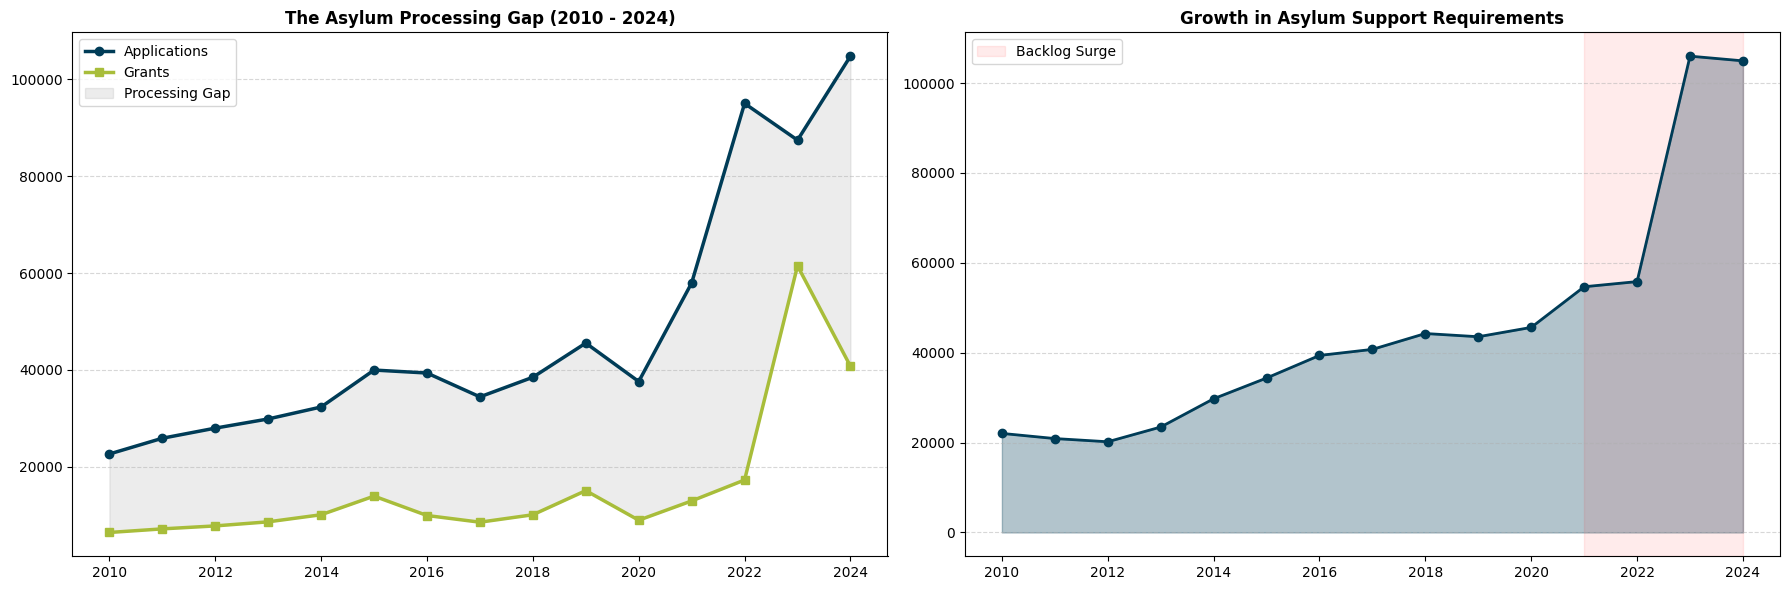

In [4]:
# ==========================================
# 2. Visualizing the Backlog and Logistical Burden
# ==========================================

# Install the missing dependency
!pip install odfpy

# Load Datasets
df_apps = load_ho_sheet('Asy_01a')
df_grants = load_ho_sheet('Asy_02a')
df_support = load_ho_sheet('Asy_09a')

# Extract Target Rows
apps_row = df_apps[df_apps['Category'] == 'Total people']
grants_row = df_grants[df_grants['Category'] == 'Asylum-related grants']
s95_row = df_support[df_support['Category'].str.contains('Section 95', na=False)]

# Extract Years (2010 - 2024)
years = [int(y) for y in df_apps.columns if y.isdigit() and len(y) == 4]
apps_vals = pd.to_numeric(apps_row[[str(y) for y in years]].values[0], errors='coerce')
grants_vals = pd.to_numeric(grants_row[[str(y) for y in years]].values[0], errors='coerce')

# Correctly extract support_vals using 'Dec YYYY' columns
support_cols_to_extract = ['Dec ' + str(y) for y in years]
support_vals = pd.to_numeric(s95_row[support_cols_to_extract].values[0], errors='coerce')

# Plotting Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: The Backlog
ax1.plot(years, apps_vals, marker='o', color='#003C57', linewidth=2.5, label='Applications')
ax1.plot(years, grants_vals, marker='s', color='#A8BD3A', linewidth=2.5, label='Grants')
ax1.fill_between(years, grants_vals, apps_vals, color='grey', alpha=0.15, label='Processing Gap')
ax1.set_title('The Asylum Processing Gap (2010 - 2024)', fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend()

# Chart 2: Operational Impact (Support)
ax2.fill_between(years, support_vals, color='#003C57', alpha=0.3)
ax2.plot(years, support_vals, color='#003C57', marker='o', linewidth=2)
ax2.axvspan(2021, 2024, color='red', alpha=0.08, label='Backlog Surge')
ax2.set_title('Growth in Asylum Support Requirements', fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

### 2. The Justice Funnel: Judicial Review of Home Office Refusals
A critical piece of the asylum pipeline is the appeals process. If the Home Office refuses an applicant, they have the right to appeal to an immigration judge. This Sankey diagram maps the flow of over 4,000 appeals, revealing a highly significant metric: **Over 52% of initial Home Office refusals are overturned by judges.**

In [9]:
# ==========================================
# 3. The Justice Funnel (Interactive Sankey)
# ==========================================
# Load Appeals Data
df_appeals = load_ho_sheet('Asy_06_07')
target_year = 'Year ending March 2023'

# Extract Pipeline Math
lodged = df_appeals.loc[df_appeals['Category'] == 'Appeals lodged', target_year].values[0]
decisions = df_appeals.loc[df_appeals['Category'] == 'Appeal decisions', target_year].values[0]
allowed = df_appeals.loc[df_appeals['Category'] == 'Allowed', target_year].values[0]
dismissed = df_appeals.loc[df_appeals['Category'] == 'Dismissed', target_year].values[0]
withdrawn = df_appeals.loc[df_appeals['Category'] == 'Withdrawn', target_year].values[0]
pending = lodged - decisions - withdrawn

# Define Sankey Nodes and Flows
nodes = ["Appeals Lodged", "Decisions Made", "Withdrawn", "Pending / Rolled Over", "Allowed (HO Overturned)", "Dismissed (HO Upheld)"]
sources = [0, 0, 0, 1, 1]
targets = [1, 2, 3, 4, 5]
values =  [decisions, withdrawn, pending, allowed, dismissed]

# Build Interactive Plotly Figure
fig = go.Figure(data=[go.Sankey(
    node = dict(pad=25, thickness=20, line=dict(color="black", width=0.5), label=nodes,
                color=["#003C57", "#003C57", "#C4C4C4", "#C4C4C4", "#A8BD3A", "#D9534F"]),
    link = dict(source=sources, target=targets, value=values,
                color=["rgba(0,60,87,0.3)", "rgba(196,196,196,0.3)", "rgba(196,196,196,0.3)", "rgba(168,189,58,0.4)", "rgba(217,83,79,0.4)"])
)])

fig.update_layout(title_text="<b>The Justice Funnel: Outcomes of Asylum Appeals</b>", font_size=12, height=500)
fig.show()